# Range-Based Volatility Estimation from Candlestick Data



## 1. Model and Notation

This project studies volatility estimation using opening, high, low and closing prices, all the reusable Python functions are stored in 'pycode/', while the following noebook shows the mathematical and theoretical explanations, together with results and charts.

Let the log price $X_t$ follow a Brownian motion with volatility $\sigma$ per day, $X_t = \sigma W_t$ on the unit interval $t \in [0,1]$ representing one session, with the open normalized to $X_0 = 0$. The bar records

$$r = X_1, \qquad h = \max_{t \le 1} X_t, \qquad l = \min_{t \le 1} X_t, \qquad R = h - l, \qquad w = R - |r|,$$

that is, the open-to-close return, the high and low in log distance from the open, the range, and the wick (the total shadow length). Where multi-day structure matters we write $o_t = \ln(O_t / C_{t-1})$ for the overnight gap. An estimator $\hat\sigma^2$ of the daily variance is **unbiased** if $\mathbb{E}[\hat\sigma^2] = \sigma^2$, and the **relative efficiency** of estimator $B$ against $A$ is $\mathrm{Var}(\hat\sigma^2_A) / \mathrm{Var}(\hat\sigma^2_B)$; since estimator variance scales as $1/n$ over $n$ independent days, efficiency is the factor by which required history shrinks at fixed precision.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pycode.simulation import exact_bar, naive_bar
from pycode.style import apply_style

apply_style() 

print('Numpy version:', np.__version__)

Numpy version: 2.5.3


## 2. Preliminary Checks 

Before starting the whole research project, I check that the simulated highs and lows contain both the open and the close. For zero drift and unit daily volatility, the Brownian reference moments are the following:
$$\mathbb{E}[R] = 2\sqrt{2/\pi}$$
$$
\mathbb{E}[R^2] = 4\ln 2 
$$ 

As a consequence, the simulated averages should approach these values as the sample grows in size.



In [2]:
rng = np.random.default_rng(7) # setting the seed for reproducibility

H, L, C = exact_bar(
    rng, 
    sigma = 1.0,
    mu = 0.0,
    m = 16,
    n_days = 100_000
)

R = H - L

assert np.all(H >= np.maximum(0.0, C))
assert np.all( L <= np.minimum(0.0, C))

mean_range = np.mean(R)
mean_squared_range = np.mean(R * R)

reference_range = 2 * np.sqrt(2/ np.pi)  # brownian motion refrence range 
reference_squared_range = 4 * np.log(2) # browninan motion refrence squared range 

print('bar bounds passed')
print('Mean range:', mean_range)
print('Reference:', reference_range)
print('Mean squared range:', mean_squared_range)
print('reference:', reference_squared_range)


bar bounds passed
Mean range: 1.5932219190879888
Reference: 1.5957691216057308
Mean squared range: 2.762729505341919
reference: 2.772588722239781


## 3. Distribution of the Extremes

Let $B_t$ be standard Brownian motion at time $t$, starting at $B_0=0$. Define its maximum as

$$
M_t=\max_{0\le s\le t}B_s
$$

In the price model, Brownian motion describes changes in **log price relative to the open**. In this case I am assumming one session $t=1$, zero drift and unit volatility.

### 3.1 The distribution of the maximum

Considering a positive level $y$, a path can reach $y$ and finish either above or below it.

Reflecting the part of a path after its first touch of $y$ turns a path ending below $y$ into one ending above $y$ and brownian symmetry makes these two groups equally likely. Every path ending above $y$ must have crossed it. Therefore,

$$
\begin{aligned}
\mathbb P(M_t\ge y)
&=\mathbb P(M_t\ge y,\ B_t<y)
  +\mathbb P(B_t\ge y)\\
&=2\,\mathbb P(B_t\ge y)
\end{aligned}
$$

Since $B_t$ has a symmetric normal distribution,

$$
\mathbb P(|B_t|\ge y)=2\,\mathbb P(B_t\ge y)
$$

The two variables have the same tail probabilities, so

$$
\boxed{M_t\overset{d}{=}|B_t|}
$$

This means **the same distribution**, not the same value on each path. At $t=1$, the maximum follows a half-normal distribution, giving

$$
\mathbb E[M_1]=\sqrt{\frac{2}{\pi}}\approx0.79788
\qquad
\mathbb E[M_1^2]=1
$$

In the left chart I draw random closes and sample their conditional maxima. The histogram should follow the half-normal curve, while the calculated moments should approach these reference values.

### 3.2 The maximum when the closing level is known

Now, supposing that the path ends at $B_t=c$, I want the probability that it crossed $y$, where $y\ge\max(0,c)$. Reflection maps a path crossing $y$ and ending at $c$ to a path ending at $2y-c$. Writing the endpoint density as

$$
p_t(z)=\frac{1}{\sqrt{2\pi t}}
       \exp\left(-\frac{z^2}{2t}\right)
$$

The conditional crossing probability is the ratio

$$
\begin{aligned}
\mathbb P(M_t\ge y\mid B_t=c)
&=
\frac{\text{density of paths crossing }y\text{ and ending at }c}
     {\text{density of paths ending at }c}\\
&=\frac{p_t(2y-c)}{p_t(c)}\\
&=\exp\left[-\frac{(2y-c)^2-c^2}{2t}\right]\\
&=\boxed{\exp\left[-\frac{2y(y-c)}{t}\right]}
\end{aligned}
$$

I use densities because an exactly specified endpoint has probability zero in a continuous distribution. The chart uses $s^2=1$ and $c=0.9$:

$$
\mathbb P(M\ge y\mid C=0.9)=\exp[-2y(y-0.9)]
$$

In the right chart, the blue line measures the fraction of simulated maxima exceeding each level, while the dashed line gives the formula above. Their agreement checks the conditional sampler. Financially, identical opening and closing prices can still accompany different intraday highs.

### 3.3 The uniform distributions $U$ and $V$

The uniform draws provide randomness for sampling the hidden extremes. We can derive a value for $M$ drawing once from $U$ setting the maximum’s survival probability equal to \(U\sim\mathrm{Uniform}(0,1)\):

$$
U=\exp\left[-\frac{2M(M-c)}{s^2}\right]
$$

I can apply this to every small step. Taking logarithms gives a quadratic:

$$
M^2-cM+\frac{s^2}{2}\ln U=0
$$

Its larger root is

$$
\boxed{
M=\frac{c+\sqrt{c^2-2s^2\ln U}}{2}
}
$$

This root respects $M\ge\max(0,c)$. By applying the same reasoning to the reflected process, we sample the minimum using $V$:

$$
\boxed{
L=\frac{c-\sqrt{c^2-2s^2\ln V}}{2}
}
$$

Our implementation draws $U$ and $V$ independently. Each formula gives the correct **individual conditional distribution**, but their combination introduces the limitation below

### 3.4 From step extremes to the daily bar

For step $j$, let $a_j$ be its starting log-price level and $d_j$ its endpoint change. The bridge formulas produce relative extremes $M_j$ and $L_j$. Adding the starting level gives the step’s extremes on the daily path:

$$
H_j=a_j+M_j,
\qquad
\ell_j=a_j+L_j
$$

Across all $m$ steps, the simulated daily bar is

$$
\boxed{
H=\max_j H_j,\qquad
L=\min_j\ell_j,\qquad
C=\sum_{j=1}^{m}d_j
}
$$

Thus, the daily high is the highest step maximum, the daily low is the lowest step minimum, and the close is the final endpoint of the accumulated changes.

### 3.5 Limitation: the hidden high and low are dependent

On a real Brownian path, the maximum and minimum come from the same journey within a fixed interval. If the path takes time to reach a high level, less time remains to reach a low level afterward, and vice versa. The order of the visits and the distance travelled connect the two extremes.

Even after fixing the endpoints, they are generally dependent, drawing their uniforms independently ignores this connection.

Consequently:

- Each extreme has the correct conditional marginal distribution
- Their joint distribution is generally incorrect
- Statistics using both extremes, such as the range $H-L$, can be biased

E[M]: 0.79778 +/- 0.00039
Reference E[M]: 0.79788
E[M²]: 0.99948 +/- 0.00101
Reference E[M²]: 1.00000


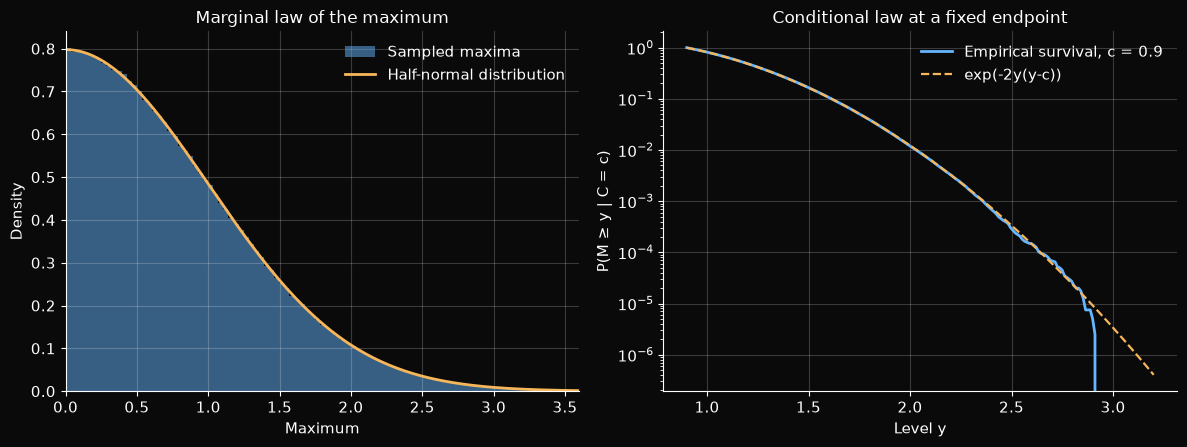

In [3]:
from pycode.simulation import bridge_max 
from pycode.statistics import chunk_stats
from pycode.plots import plot_maximum_laws

rng = np.random.default_rng(20260801) 
N = 2_000_000

c = rng.normal(0.0, 1.0, N) # sampling the closing prices from a std normal
u = rng.uniform(size = N) # generate the uniform variable for the bridge formula 
m = bridge_max(c, 1.0, u) # sampling the maxima for the bridge formula

mean, se = chunk_stats(m)      # checking the first moment of the maxima 
mean2, se2 = chunk_stats(m*m)  # checking the second moment of the maxima


print(f"E[M]: {mean:.5f} +/- {se:.5f}")  # Print five decimal places
print(f"Reference E[M]: {np.sqrt(2 / np.pi):.5f}")  # Print the theoretical mean
print(f"E[M²]: {mean2:.5f} +/- {se2:.5f}")  # Print the second moment
print("Reference E[M²]: 1.00000")  # Print its theoretical value

c0 = 0.9 # same closing price fo all the bars, after they start at zero
u0 = rng.uniform(size=400_000) # generate new random variables
m0 = bridge_max(c0, 1.0, u0) # sampling the maxima for paths finishing at 0.9

ys = np.linspace(c0, 3.2, 200) # create 200 thresolds between 0.9 to 3.2 
emp = (m0[None, :] >= ys[:, None]).mean(axis=1) #estimating the exceedance prob for each threshold

# theoretical exceedence probability for a brownian bridge with a closing price of 0.9
theo = np.exp(-2 * ys * (ys - c0)) 

fig = plot_maximum_laws(m, ys, emp, theo, c0)
plt.show()